In [2]:
import os
import pandas as pd
from typing import Dict, List, Tuple
from pathlib import Path
import sys
import contextlib
import cv2
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
import random
import torch
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from typing import Any, Optional, Union, List

cv2.setNumThreads(1)

In [3]:
OUT_DIR = "/home/infres/yrothlin-24/CHAL_IM05/machine_learning/outputs"


label2id = {
    "SNE": 0, "LY": 1, "MO": 2, "EO": 3, "BA": 4, "VLY": 5, "BNE": 6, "MMY": 7, "MY": 8, "PMY": 9, "BL": 10, "PC": 11, "PLY": 12,
}

train_dir = "/tsi/data_education/ChallengeIMA205/IMA205-challenge/train"
train_label_path = "/tsi/data_education/ChallengeIMA205/IMA205-challenge/train_metadata.csv"

test_dir = "/tsi/data_education/ChallengeIMA205/IMA205-challenge/test"
test_label_path = "/tsi/data_education/ChallengeIMA205/IMA205-challenge/test_metadata.csv"

In [4]:
def get_filespath(dataset_dir: str) -> List[str]:
    files = []
    for dirpath, _, filenames in os.walk(dataset_dir):
        for filename in filenames:
            if filename.endswith(".png"):
                files.append(os.path.join(dirpath, filename))
    files.sort()
    return files


def get_labels(csv_path: str) -> Dict[str, int]:
    df = pd.read_csv(csv_path)
    labels = {}
    for _, row in df.iterrows():
        labels[str(row["ID"])] = label2id[str(row["label"])]
    return labels


def get_base_id(filename: str) -> str:
    p = Path(filename)
    stem = p.stem
    suffix = p.suffix
    marker = "_aug_"
    if marker in stem:
        stem = stem.split(marker)[0]
    return f"{stem}{suffix}"

@contextlib.contextmanager
def _filter_stderr(substr: str):
    r_fd, w_fd = os.pipe()
    orig_fd = os.dup(2)
    os.dup2(w_fd, 2)
    os.close(w_fd)
    try:
        yield
    finally:
        os.dup2(orig_fd, 2)
        os.close(orig_fd)
        with os.fdopen(r_fd, "r") as r:
            for line in r:
                if substr not in line:
                    sys.stderr.write(line)

def imread_silent(path: str):
    with _filter_stderr("Corrupt JPEG data"):
        return cv2.imread(path, cv2.IMREAD_COLOR)


In [5]:
class Metrics:
    def __init__(self, labels=None, zero_division=0.0):
        self.labels = None if labels is None else np.asarray(labels)
        self.zero_division = float(zero_division)
        self._y_true = []
        self._y_pred = []

    def reset(self):
        self._y_true.clear()
        self._y_pred.clear()

    def update(self, y_true, y_pred):
        y_true = np.asarray(y_true).ravel()
        y_pred = np.asarray(y_pred).ravel()
        self._y_true.append(y_true)
        self._y_pred.append(y_pred)

    def compute(self):
        y_true = np.concatenate(self._y_true)
        y_pred = np.concatenate(self._y_pred)

        labels = self.labels
        if labels is None:
            labels = np.unique(np.concatenate([y_true, y_pred]))

        n = len(labels)
        idx = {c: i for i, c in enumerate(labels)}

        cm = np.zeros((n, n), dtype=float)
        for t, p in zip(y_true, y_pred):
            cm[idx[t], idx[p]] += 1

        tp = np.diag(cm)
        fp = cm.sum(axis=0) - tp
        fn = cm.sum(axis=1) - tp

        precision = np.divide(
            tp, tp + fp,
            out=np.full(n, self.zero_division),
            where=(tp + fp) != 0
        )

        recall = np.divide(
            tp, tp + fn,
            out=np.full(n, self.zero_division),
            where=(tp + fn) != 0
        )

        f1 = np.divide(
            2 * precision * recall,
            precision + recall,
            out=np.full(n, self.zero_division),
            where=(precision + recall) != 0
        )

        return {
            "confusion_matrix": cm,
            "bacc": recall.mean(),
            "precision": precision,
            "recall": recall,
            "f1": f1,
            "macro_f1": f1.mean(),
        }

In [6]:
def build_dataset(
    train_dir: str,
    train_csv: str,
    test_dir: str
) -> Tuple[List[np.ndarray], np.ndarray, List[np.ndarray]]:

    train_files = get_filespath(train_dir)
    test_files = get_filespath(test_dir)

    train_labels_dict = get_labels(train_csv)

    X_train, y_train = [], []
    X_test = []

    for path in train_files:
        img = imread_silent(path)
        if img is None:
            continue
        base_id = get_base_id(path)
        if base_id not in train_labels_dict:
            continue
        X_train.append(img)
        y_train.append(train_labels_dict[base_id])

    for path in test_files:
        img = imread_silent(path)
        if img is None:
            continue
        X_test.append(img)

    return X_train, np.array(y_train), X_test

In [7]:
X_train, y_train, X_test = build_dataset(
    train_dir,
    train_label_path,
    test_dir
)

In [8]:
print(f"Number of training samples: {len(X_train)}")
print(f"Number of testing samples: {len(X_test)}")
print(f"Number of classes: {len(set(y_train))}")


Number of training samples: 28901
Number of testing samples: 9634
Number of classes: 13


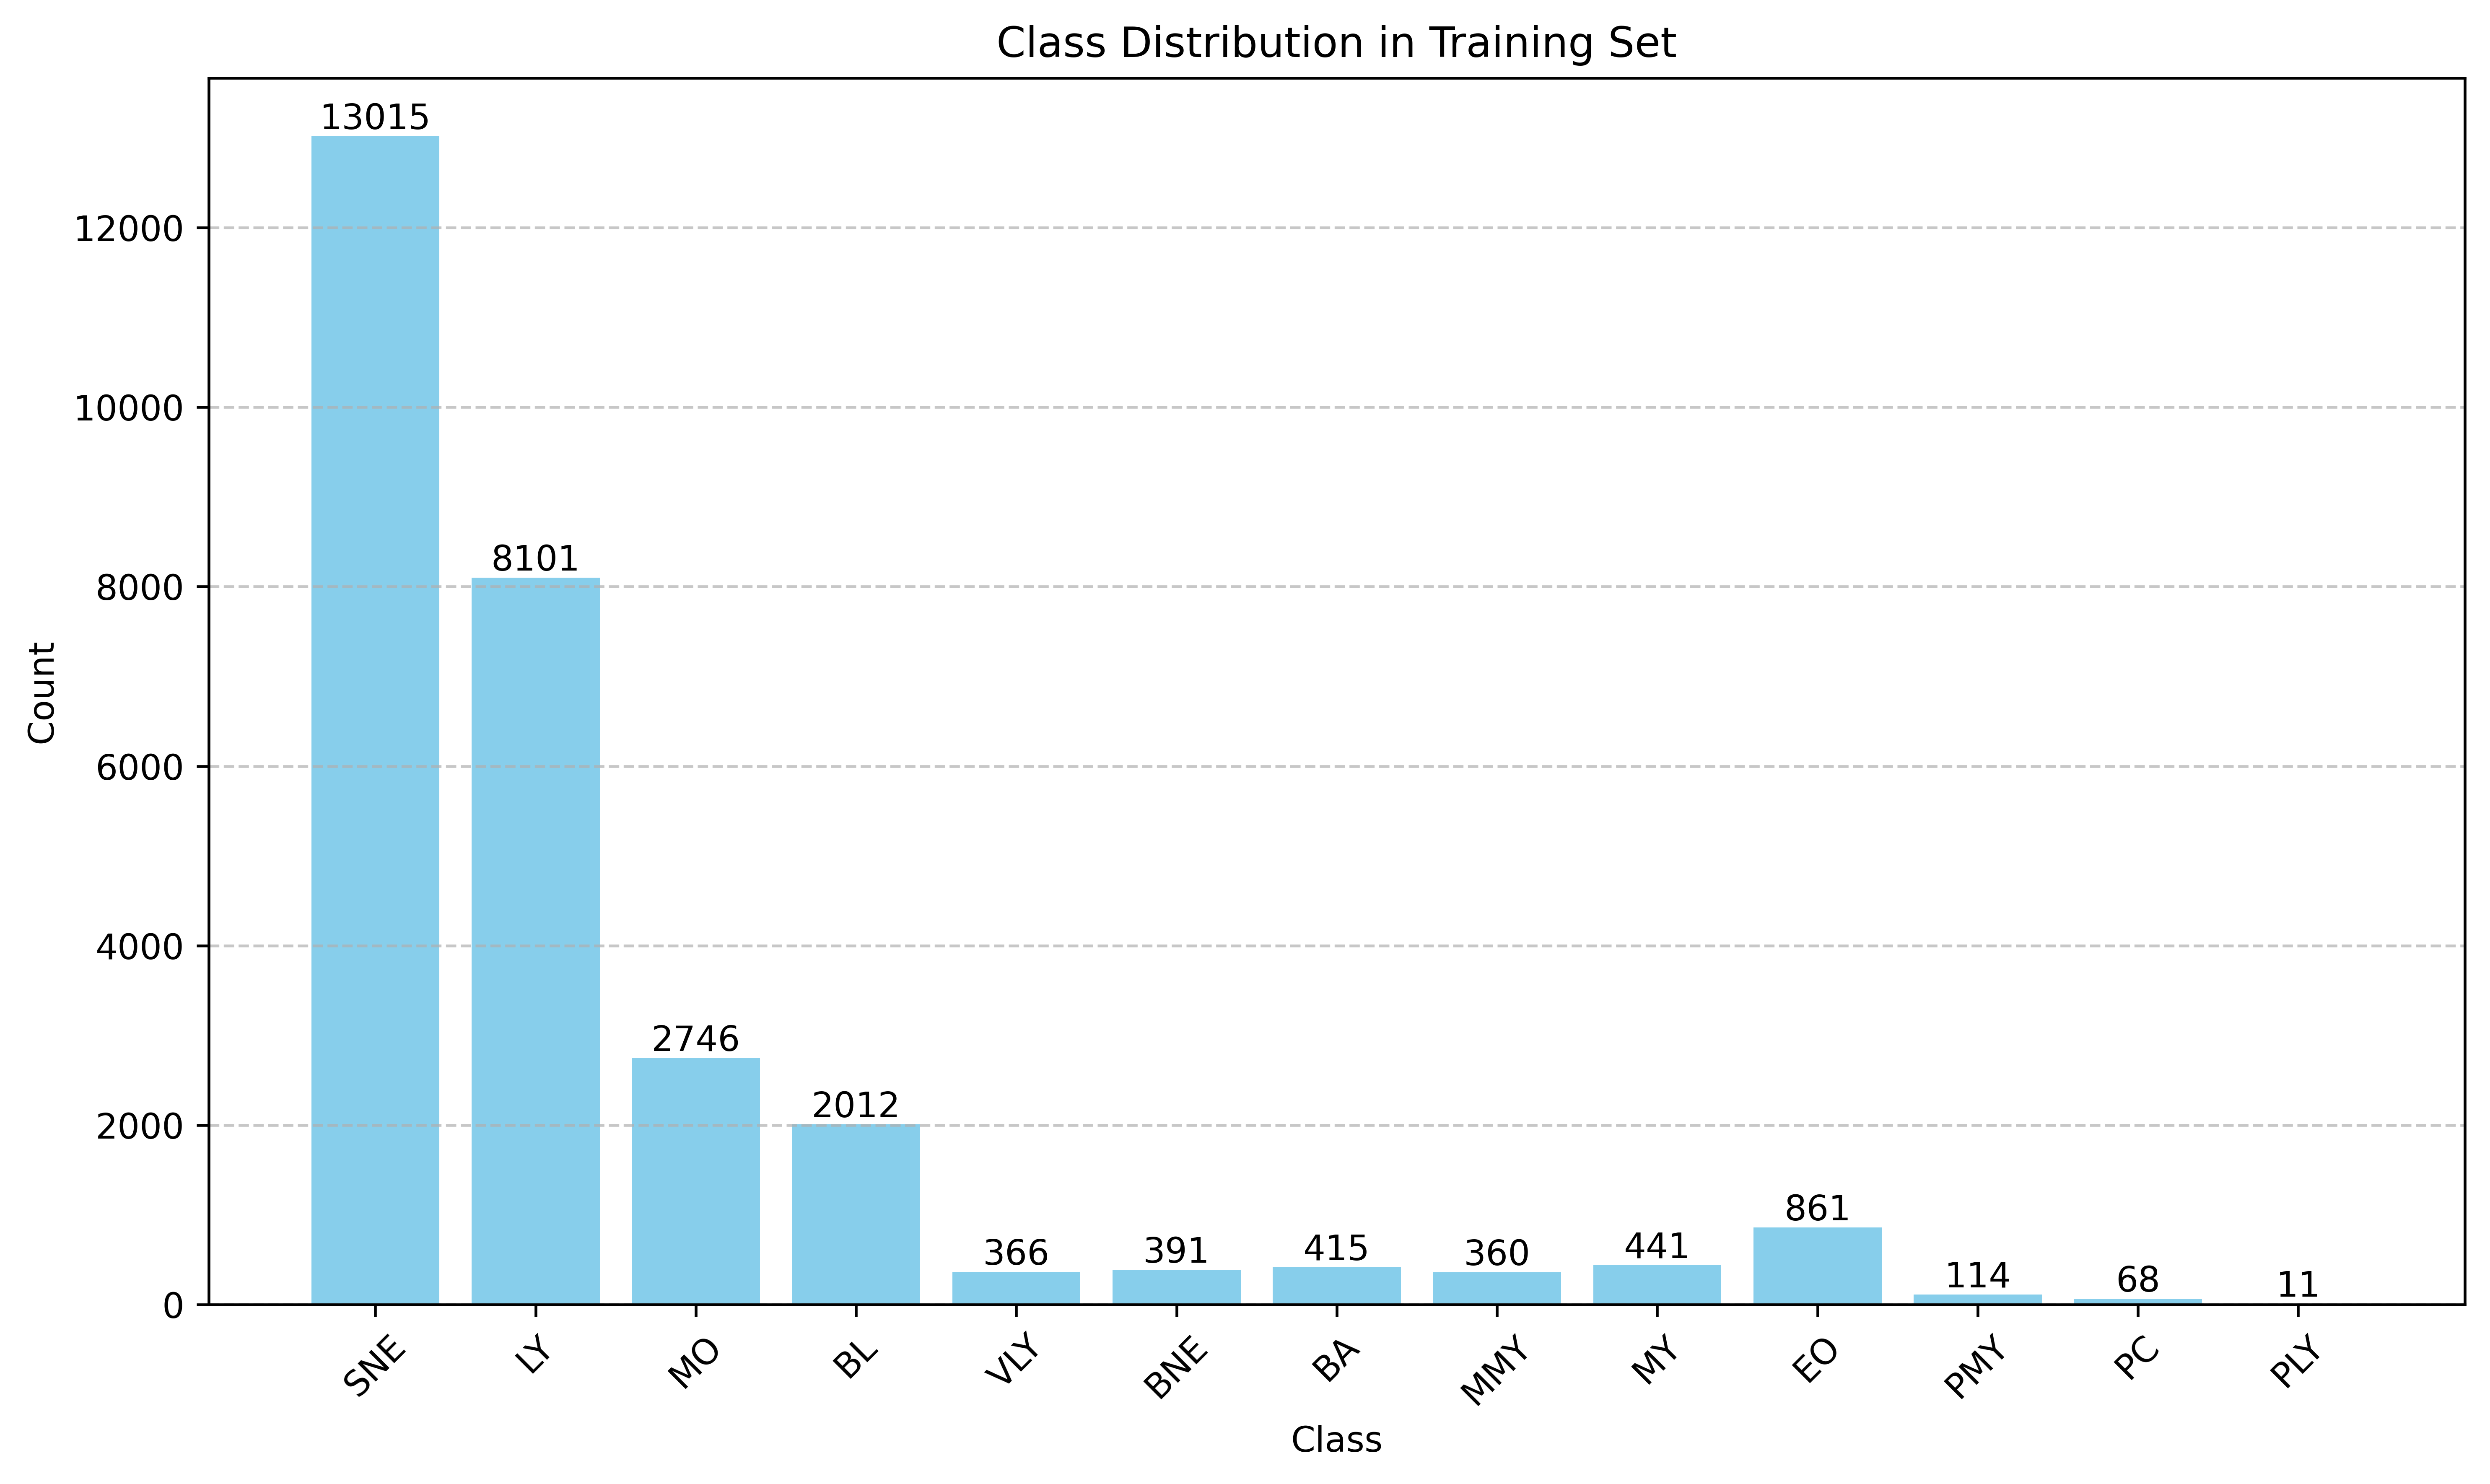

In [21]:
def plot_class_distribution(y: np.ndarray, title: str, label2id: dict):
    counter = Counter(y)
    classes = list(counter.keys())
    counts = list(counter.values())

    id2label = {v: k for k, v in label2id.items()}
    class_names = [id2label[c] for c in classes]

    plt.figure(figsize=(10, 6), dpi=600)
    bars = plt.bar(range(len(classes)), counts, color='skyblue')

    for bar, count in zip(bars, counts):
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height(),
            str(count),
            ha='center',
            va='bottom'
        )

    plt.xlabel('Class')
    plt.ylabel('Count')
    plt.title(title)
    plt.xticks(range(len(classes)), class_names, rotation=45)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

plot_class_distribution(y_train, "Class Distribution in Training Set", label2id)

# PREPROCESSING

In [22]:

K1 = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
K_MID = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (21, 21))
K_BIG = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (45, 45))


def preprocess(img: np.ndarray, size=(160, 160)) -> np.ndarray:
    img = cv2.resize(img, size, interpolation=cv2.INTER_AREA)

    lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
    lab[:, :, 0] = cv2.equalizeHist(lab[:, :, 0])
    img = cv2.cvtColor(lab, cv2.COLOR_LAB2BGR)

    img = cv2.GaussianBlur(img, (5, 5), 0)
    return img


def _select_best_component(stats, min_area, cx0, cy0):
    if stats.shape[0] <= 1:
        return None

    left = stats[1:, cv2.CC_STAT_LEFT].astype(np.float32)
    top = stats[1:, cv2.CC_STAT_TOP].astype(np.float32)
    width = stats[1:, cv2.CC_STAT_WIDTH].astype(np.float32)
    height = stats[1:, cv2.CC_STAT_HEIGHT].astype(np.float32)
    area = stats[1:, cv2.CC_STAT_AREA].astype(np.float32)

    valid = area >= min_area
    if not np.any(valid):
        return None

    cx = left + 0.5 * width
    cy = top + 0.5 * height
    d2 = (cx - cx0) ** 2 + (cy - cy0) ** 2
    score = np.where(valid, np.log1p(area) - 0.0008 * d2, -1e18)

    best_local = int(np.argmax(score))
    if score[best_local] < -1e17:
        return None

    return best_local + 1


def extract_cell_mask(
    img: np.ndarray,
    min_area_frac: float = 0.0005,
    q: float = 0.92,
    work_size=(160, 160),
    grabcut_iter: int = 2,
) -> np.ndarray:
    h0, w0 = img.shape[:2]
    proc = preprocess(img, size=work_size)
    h, w = proc.shape[:2]

    hsv = cv2.cvtColor(proc, cv2.COLOR_BGR2HSV)
    H = hsv[:, :, 0].astype(np.float32)
    S = hsv[:, :, 1].astype(np.float32)
    V = hsv[:, :, 2].astype(np.float32)

    dh = np.abs(H - 140.0)
    hdist = np.minimum(dh, 180.0 - dh) / 90.0
    hscore = 1.0 - np.clip(hdist, 0.0, 1.0)
    sscore = np.clip((S - 30.0) / 225.0, 0.0, 1.0)
    vscore = 1.0 - np.clip(V / 255.0, 0.0, 1.0)

    score = 0.55 * hscore + 0.25 * sscore + 0.20 * vscore
    thr = np.quantile(score, q)
    nuc = (score >= thr).astype(np.uint8) * 255

    nuc = cv2.medianBlur(nuc, 5)
    nuc = cv2.morphologyEx(nuc, cv2.MORPH_OPEN, K1, iterations=1)
    nuc = cv2.morphologyEx(nuc, cv2.MORPH_CLOSE, K1, iterations=2)

    num, labels, stats, _ = cv2.connectedComponentsWithStats(nuc, connectivity=8)
    if num <= 1:
        return np.zeros((h0, w0), dtype=np.uint8)

    min_area = int(min_area_frac * h * w)
    cx0, cy0 = w * 0.5, h * 0.5
    best_i = _select_best_component(stats, min_area, cx0, cy0)

    if best_i is None:
        return np.zeros((h0, w0), dtype=np.uint8)

    nuc = np.zeros((h, w), dtype=np.uint8)
    nuc[labels == best_i] = 255

    probable_fg = cv2.dilate(nuc, K_BIG, iterations=1)
    probable_fg = cv2.morphologyEx(probable_fg, cv2.MORPH_CLOSE, K_MID, iterations=1)

    pts = cv2.findNonZero(probable_fg)
    if pts is None:
        return np.zeros((h0, w0), dtype=np.uint8)

    x, y, rw, rh = cv2.boundingRect(pts)

    pad = 8
    x1 = max(0, x - pad)
    y1 = max(0, y - pad)
    x2 = min(w, x + rw + pad)
    y2 = min(h, y + rh + pad)

    roi_img = proc[y1:y2, x1:x2]
    roi_nuc = nuc[y1:y2, x1:x2]
    roi_fg = probable_fg[y1:y2, x1:x2]

    gc_mask = np.full(roi_fg.shape, cv2.GC_BGD, dtype=np.uint8)
    gc_mask[roi_fg > 0] = cv2.GC_PR_FGD
    gc_mask[roi_nuc > 0] = cv2.GC_FGD

    sure_bg = cv2.dilate(roi_fg, K_BIG, iterations=1)
    sure_bg = cv2.bitwise_not(sure_bg)
    gc_mask[sure_bg > 0] = cv2.GC_BGD

    bgd_model = np.zeros((1, 65), np.float64)
    fgd_model = np.zeros((1, 65), np.float64)

    rect = (0, 0, roi_img.shape[1], roi_img.shape[0])
    cv2.grabCut(roi_img, gc_mask, rect, bgd_model, fgd_model, grabcut_iter, cv2.GC_INIT_WITH_MASK)

    roi_mask = np.where(
        (gc_mask == cv2.GC_FGD) | (gc_mask == cv2.GC_PR_FGD),
        255,
        0
    ).astype(np.uint8)

    roi_mask = cv2.morphologyEx(roi_mask, cv2.MORPH_CLOSE, K_MID, iterations=1)
    roi_mask = cv2.morphologyEx(roi_mask, cv2.MORPH_OPEN, K1, iterations=1)

    num2, labels2, stats2, _ = cv2.connectedComponentsWithStats(roi_mask, connectivity=8)
    if num2 > 1:
        best_j = _select_best_component(stats2, 1, roi_mask.shape[1] * 0.5, roi_mask.shape[0] * 0.5)
        if best_j is not None:
            clean = np.zeros_like(roi_mask)
            clean[labels2 == best_j] = 255
            roi_mask = clean

    final_mask = np.zeros((h, w), dtype=np.uint8)
    final_mask[y1:y2, x1:x2] = roi_mask
    final_mask = cv2.resize(final_mask, (w0, h0), interpolation=cv2.INTER_NEAREST)

    return final_mask


def mask_to_binary(mask: np.ndarray) -> np.ndarray:
    return (mask > 0).astype(np.uint8)


def get_mask_bbox(mask: np.ndarray):
    ys, xs = np.where(mask > 0)
    if xs.size == 0 or ys.size == 0:
        return None
    return xs.min(), ys.min(), xs.max(), ys.max()


def crop_to_mask(img: np.ndarray, mask: np.ndarray, padding: int = 2):
    bbox = get_mask_bbox(mask)
    if bbox is None:
        return img, mask

    x_min, y_min, x_max, y_max = bbox
    x_min = max(0, x_min - padding)
    y_min = max(0, y_min - padding)
    x_max = min(img.shape[1] - 1, x_max + padding)
    y_max = min(img.shape[0] - 1, y_max + padding)

    return img[y_min:y_max + 1, x_min:x_max + 1], mask[y_min:y_max + 1, x_min:x_max + 1]

Cell mask extracted in 0.04 seconds.


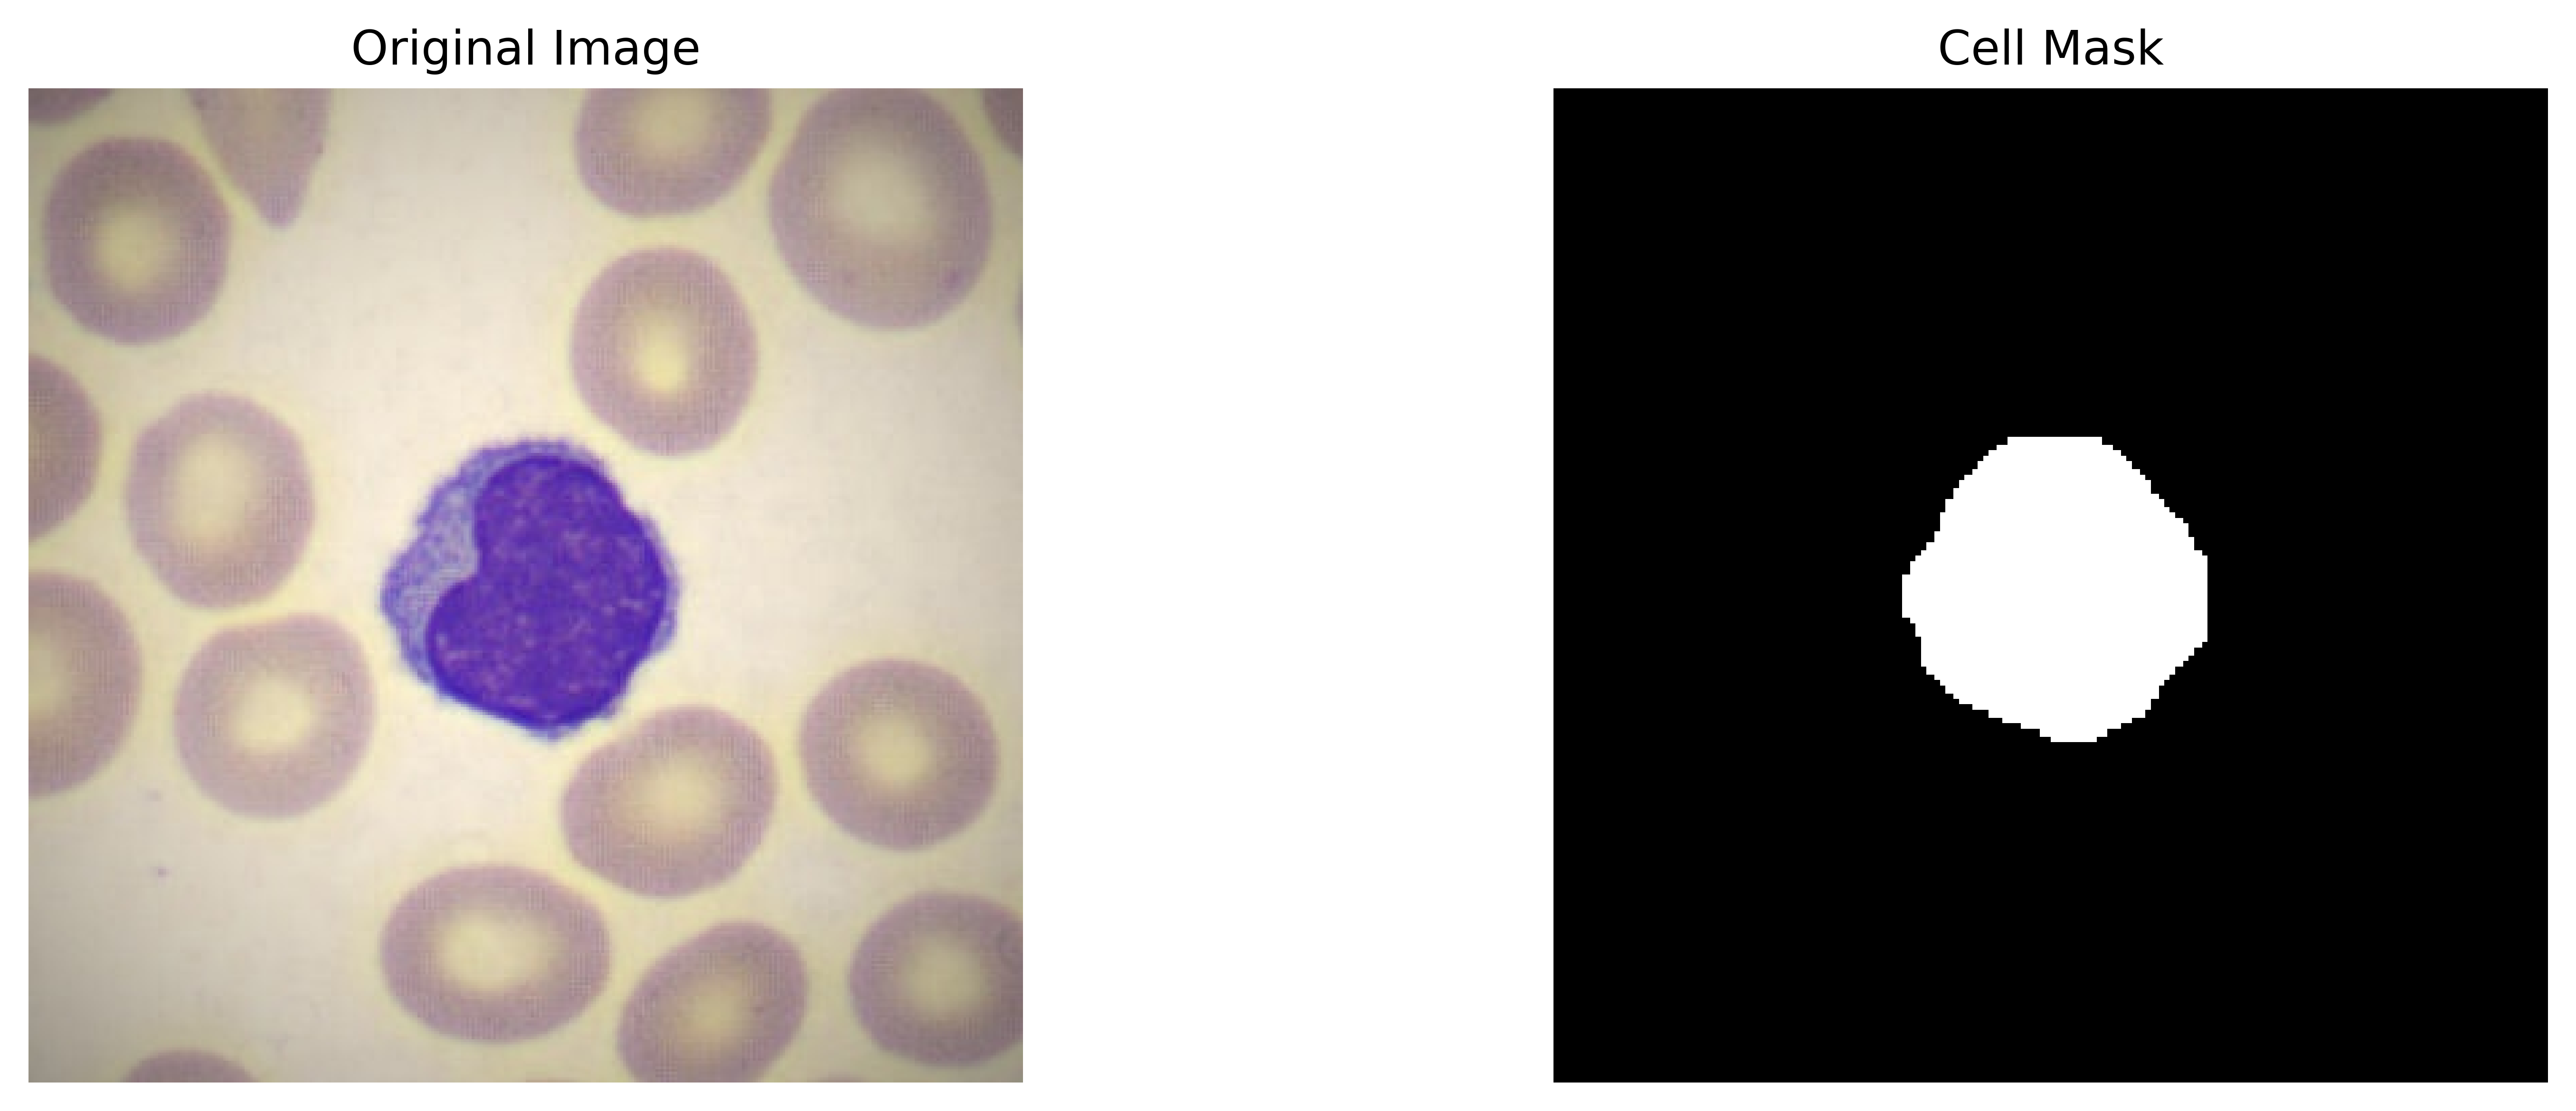

In [23]:
import time
i = np.random.randint(0, len(X_train))
img = X_train[i]
t0 = time.time()
mask = extract_cell_mask(img)
t1 = time.time()
print(f"Cell mask extracted in {t1 - t0:.2f} seconds.")


plt.figure(figsize=(12, 4), dpi=600)
plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title("Original Image")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(mask, cmap='gray')
plt.title("Cell Mask")
plt.axis('off')

plt.tight_layout()
plt.show()  

# FEATURES EXTRACTION

In [24]:
import cv2
import numpy as np
from skimage.feature import graycomatrix, graycoprops, local_binary_pattern
from skimage.measure import regionprops, label
from skimage.morphology import remove_small_holes
from scipy.stats import skew, kurtosis
import pywt
import warnings
warnings.filterwarnings("ignore")

def _safe_regionprops(mask: np.ndarray):
    m = (mask > 0).astype(np.uint8)
    lab = label(m)
    props = regionprops(lab)
    if not props:
        return None
    props = sorted(props, key=lambda p: p.area, reverse=True)
    return props[0]


def _masked_gray(img: np.ndarray, mask: np.ndarray) -> np.ndarray:
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    gray = gray.copy()
    gray[mask == 0] = 0
    return gray


def _masked_pixels(img: np.ndarray, mask: np.ndarray) -> np.ndarray:
    return img[mask > 0]


def _boundary_distances(cnt: np.ndarray, cx: float, cy: float) -> np.ndarray:
    pts = cnt[:, 0, :]
    d = np.sqrt((pts[:, 0] - cx) ** 2 + (pts[:, 1] - cy) ** 2)
    return d


def extract_shape_features(mask: np.ndarray) -> np.ndarray:
    mask = (mask > 0).astype(np.uint8)

    area = float(np.sum(mask))
    if area == 0:
        return np.zeros(18, dtype=np.float32)

    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if len(contours) == 0:
        return np.zeros(18, dtype=np.float32)

    cnt = max(contours, key=cv2.contourArea)
    perimeter = float(cv2.arcLength(cnt, True))
    x, y, w, h = cv2.boundingRect(cnt)
    bbox_area = float(w * h)

    circularity = 4.0 * np.pi * area / (perimeter ** 2) if perimeter > 0 else 0.0
    aspect_ratio = float(w) / float(h) if h > 0 else 0.0
    extent = area / bbox_area if bbox_area > 0 else 0.0

    hull = cv2.convexHull(cnt)
    convex_area = float(cv2.contourArea(hull))
    solidity = area / convex_area if convex_area > 0 else 0.0

    filled = remove_small_holes(mask.astype(bool), max_size=63)
    filled_area = float(np.sum(filled))

    num_components, _, stats, _ = cv2.connectedComponentsWithStats(mask, connectivity=8)
    num_parts = float(max(0, num_components - 1))

    rp = _safe_regionprops(mask)
    major_axis = float(rp.axis_major_length) if rp is not None else 0.0
    minor_axis = float(rp.axis_minor_length) if rp is not None else 0.0
    eccentricity = float(rp.eccentricity) if rp is not None else 0.0
    orientation = float(rp.orientation) if rp is not None else 0.0
    equivalent_diameter = float(rp.equivalent_diameter_area) if rp is not None else 0.0

    if rp is not None:
        cy, cx = rp.centroid
    else:
        M = cv2.moments(cnt)
        if M["m00"] > 0:
            cx = M["m10"] / M["m00"]
            cy = M["m01"] / M["m00"]
        else:
            cx, cy = 0.0, 0.0

    d = _boundary_distances(cnt, cx, cy)
    boundary_mean = float(np.mean(d)) if d.size else 0.0
    boundary_var = float(np.var(d)) if d.size else 0.0

    rectangularity = area / bbox_area if bbox_area > 0 else 0.0
    compactness = (perimeter ** 2) / (4.0 * np.pi * area) if area > 0 else 0.0

    return np.array([
        area,
        perimeter,
        circularity,
        aspect_ratio,
        extent,
        convex_area,
        solidity,
        filled_area,
        major_axis,
        minor_axis,
        eccentricity,
        orientation,
        equivalent_diameter,
        rectangularity,
        compactness,
        num_parts,
        boundary_mean,
        boundary_var,
    ], dtype=np.float32)


def extract_shape_ratio_features(cell_mask: np.ndarray, nucleus_mask: np.ndarray = None) -> np.ndarray:
    if nucleus_mask is None:
        return np.zeros(4, dtype=np.float32)

    cell = (cell_mask > 0).astype(np.uint8)
    nuc = (nucleus_mask > 0).astype(np.uint8)

    cell_area = float(np.sum(cell))
    nuc_area = float(np.sum(nuc))
    cyto_area = max(cell_area - nuc_area, 0.0)

    contours_cell, _ = cv2.findContours(cell, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    contours_nuc, _ = cv2.findContours(nuc, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    cell_peri = float(cv2.arcLength(max(contours_cell, key=cv2.contourArea), True)) if contours_cell else 0.0
    nuc_peri = float(cv2.arcLength(max(contours_nuc, key=cv2.contourArea), True)) if contours_nuc else 0.0

    ratio_area = nuc_area / cell_area if cell_area > 0 else 0.0
    ratio_cyto = cyto_area / cell_area if cell_area > 0 else 0.0
    ratio_peri = nuc_peri / cell_peri if cell_peri > 0 else 0.0

    return np.array([cell_area, nuc_area, ratio_area, ratio_cyto, ratio_peri][:4], dtype=np.float32)


def extract_color_features(img: np.ndarray, mask: np.ndarray) -> np.ndarray:
    mask = (mask > 0).astype(np.uint8)
    if np.sum(mask) == 0:
        return np.zeros(36, dtype=np.float32)

    bgr_pixels = _masked_pixels(img, mask)
    rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    rgb_pixels = _masked_pixels(rgb, mask)
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    hsv_pixels = _masked_pixels(hsv, mask)
    lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
    lab_pixels = _masked_pixels(lab, mask)

    def stats_block(pixels: np.ndarray) -> np.ndarray:
        mean = pixels.mean(axis=0)
        std = pixels.std(axis=0)
        sk = np.array([skew(pixels[:, i]) if len(pixels) > 2 else 0.0 for i in range(pixels.shape[1])], dtype=np.float32)
        ku = np.array([kurtosis(pixels[:, i]) if len(pixels) > 3 else 0.0 for i in range(pixels.shape[1])], dtype=np.float32)
        return np.concatenate([mean, std, sk, ku]).astype(np.float32)

    return np.concatenate([
        stats_block(bgr_pixels),
        stats_block(rgb_pixels),
        stats_block(hsv_pixels),
        stats_block(lab_pixels),
    ]).astype(np.float32)


def extract_rgb_raw_features(img: np.ndarray, size=(32, 32)) -> np.ndarray:
    rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    rgb = cv2.resize(rgb, size, interpolation=cv2.INTER_AREA)
    return rgb.flatten().astype(np.float32)


def extract_rgb_hist_features(img: np.ndarray, mask: np.ndarray = None, bins: int = 16) -> np.ndarray:
    if mask is not None:
        mask = (mask > 0).astype(np.uint8) * 255

    feats = []
    for ch in range(3):
        hist = cv2.calcHist([img], [ch], mask, [bins], [0, 256]).flatten()
        hist = hist / (hist.sum() + 1e-8)
        feats.append(hist.astype(np.float32))
    return np.concatenate(feats).astype(np.float32)


def extract_multi_hist_features(img, mask):
    feats = []

    for color_space in [
        cv2.COLOR_BGR2RGB,
        cv2.COLOR_BGR2HSV,
        cv2.COLOR_BGR2LAB
    ]:
        converted = cv2.cvtColor(img, color_space)
        for ch in range(3):
            hist = cv2.calcHist(
                [converted],
                [ch],
                (mask > 0).astype(np.uint8) * 255,
                [16],
                [0, 256]
            ).flatten()
            hist = hist / (hist.sum() + 1e-8)
            feats.append(hist)

    return np.concatenate(feats).astype(np.float32)



def extract_glcm_features(img: np.ndarray, mask: np.ndarray, levels: int = 32) -> np.ndarray:
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    if np.sum(mask > 0) == 0:
        return np.zeros(24, dtype=np.float32)

    ys, xs = np.where(mask > 0)
    y1, y2 = ys.min(), ys.max()
    x1, x2 = xs.min(), xs.max()

    roi_gray = gray[y1:y2 + 1, x1:x2 + 1].copy()
    roi_mask = (mask[y1:y2 + 1, x1:x2 + 1] > 0)

    roi_gray[~roi_mask] = 0
    roi_gray = (roi_gray / (256 / levels)).astype(np.uint8)
    roi_gray = np.clip(roi_gray, 0, levels - 1)

    glcm = graycomatrix(
        roi_gray,
        distances=[1],
        angles=[0, np.pi / 4, np.pi / 2, 3 * np.pi / 4],
        levels=levels,
        symmetric=True,
        normed=True,
    )

    props = []
    for prop in ["contrast", "dissimilarity", "homogeneity", "ASM", "energy", "correlation"]:
        vals = graycoprops(glcm, prop)[0]
        props.extend([np.mean(vals), np.std(vals)])

    p = glcm[:, :, 0, :]
    p = p / (np.sum(p) + 1e-12)
    entropy = -np.sum(p * np.log2(p + 1e-12))

    return np.concatenate([np.array(props, dtype=np.float32), np.array([entropy], dtype=np.float32)]).astype(np.float32)


def extract_haralick_like_features(img: np.ndarray, mask: np.ndarray, levels: int = 32) -> np.ndarray:
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    if np.sum(mask > 0) == 0:
        return np.zeros(8, dtype=np.float32)

    ys, xs = np.where(mask > 0)
    y1, y2 = ys.min(), ys.max()
    x1, x2 = xs.min(), xs.max()

    roi_gray = gray[y1:y2 + 1, x1:x2 + 1].copy()
    roi_mask = (mask[y1:y2 + 1, x1:x2 + 1] > 0)
    roi_gray[~roi_mask] = 0
    roi_gray = (roi_gray / (256 / levels)).astype(np.uint8)
    roi_gray = np.clip(roi_gray, 0, levels - 1)

    glcm = graycomatrix(
        roi_gray,
        distances=[1],
        angles=[0, np.pi / 4, np.pi / 2, 3 * np.pi / 4],
        levels=levels,
        symmetric=True,
        normed=True,
    )

    feats = []
    for prop in ["contrast", "homogeneity", "energy", "correlation"]:
        vals = graycoprops(glcm, prop)[0]
        feats.extend([np.mean(vals), np.std(vals)])
    return np.array(feats, dtype=np.float32)


def extract_lbp_features(img: np.ndarray, mask: np.ndarray, radii=(1, 2, 3), points=(8, 16, 24), bins: int = 16) -> np.ndarray:
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    mask = (mask > 0).astype(np.uint8)
    if np.sum(mask) == 0:
        return np.zeros(len(radii) * (bins + 3), dtype=np.float32)

    feats = []
    for r, p in zip(radii, points):
        lbp = local_binary_pattern(gray, P=p, R=r, method="uniform")
        vals = lbp[mask > 0]

        hist, _ = np.histogram(vals, bins=bins, range=(0, bins), density=True)
        feats.extend(hist.astype(np.float32))

        gray_vals = gray[mask > 0].astype(np.float32)
        feats.append(float(np.var(gray_vals)))
        feats.append(float(np.mean(vals)))
        feats.append(float(np.var(vals)))

    return np.array(feats, dtype=np.float32)


def extract_wavelet_features(img: np.ndarray, mask: np.ndarray, wavelet: str = "db1") -> np.ndarray:
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY).astype(np.float32)
    if np.sum(mask > 0) == 0:
        return np.zeros(12, dtype=np.float32)

    gray = gray.copy()
    gray[mask == 0] = 0

    coeffs2 = pywt.dwt2(gray, wavelet)
    cA, (cH, cV, cD) = coeffs2

    feats = []
    for c in [cA, cH, cV, cD]:
        feats.extend([
            float(np.mean(c)),
            float(np.std(c)),
            float(np.energy(c) if hasattr(np, "energy") else np.sum(c ** 2)),
        ])
    return np.array(feats, dtype=np.float32)


def extract_intensity_statistics(img: np.ndarray, mask: np.ndarray) -> np.ndarray:
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    vals = gray[mask > 0]
    if len(vals) == 0:
        return np.zeros(6, dtype=np.float32)

    return np.array([
        float(np.mean(vals)),
        float(np.std(vals)),
        float(np.min(vals)),
        float(np.max(vals)),
        float(skew(vals)) if len(vals) > 2 else 0.0,
        float(kurtosis(vals)) if len(vals) > 3 else 0.0,
    ], dtype=np.float32)


def extract_all_handcrafted_features(
    img: np.ndarray,
    cell_mask: np.ndarray,
    nucleus_mask: np.ndarray = None,
    rgb_raw_size=(32, 32),
    rgb_hist_bins: int = 16,
) -> np.ndarray:
    cell_mask = (cell_mask > 0).astype(np.uint8)

    feats = [
        extract_shape_features(cell_mask),
        extract_shape_ratio_features(cell_mask, nucleus_mask),
        extract_color_features(img, cell_mask),
        extract_intensity_statistics(img, cell_mask),
        extract_glcm_features(img, cell_mask),
        extract_haralick_like_features(img, cell_mask),
        extract_lbp_features(img, cell_mask),
        # extract_rgb_hist_features(img, cell_mask, bins=rgb_hist_bins),
        extract_multi_hist_features(img, cell_mask),
        # extract_rgb_raw_features(img, size=rgb_raw_size),
        extract_wavelet_features(img, cell_mask),
    ]

    return np.concatenate(feats).astype(np.float32)


def extract_feature_dict(
    img: np.ndarray,
    cell_mask: np.ndarray,
    nucleus_mask: np.ndarray = None,
    rgb_raw_size=(32, 32),
    rgb_hist_bins: int = 16,
):
    return {
        "shape": extract_shape_features(cell_mask),
        "shape_ratio": extract_shape_ratio_features(cell_mask, nucleus_mask),
        "color": extract_color_features(img, cell_mask),
        "intensity": extract_intensity_statistics(img, cell_mask),
        "glcm": extract_glcm_features(img, cell_mask),
        "haralick_like": extract_haralick_like_features(img, cell_mask),
        "lbp": extract_lbp_features(img, cell_mask),
        "rgb_hist": extract_rgb_hist_features(img, cell_mask, bins=rgb_hist_bins),
        "rgb_raw": extract_rgb_raw_features(img, size=rgb_raw_size),
        "wavelet": extract_wavelet_features(img, cell_mask),
        "all": extract_all_handcrafted_features(
            img,
            cell_mask,
            nucleus_mask=nucleus_mask,
            rgb_raw_size=rgb_raw_size,
            rgb_hist_bins=rgb_hist_bins,
        ),
    }




In [25]:
from concurrent.futures import ThreadPoolExecutor
from functools import partial
from tqdm.auto import tqdm
import os
import cv2

cv2.setNumThreads(1)


def compute_mask(img):
    return extract_cell_mask(img)


def compute_features_from_img_and_mask(args):
    img, mask = args
    return extract_all_handcrafted_features(img, mask)


def parallel_map_thread(fn, data, max_workers=None, desc=None):
    if max_workers is None:
        max_workers = min(8, os.cpu_count() or 1)

    with ThreadPoolExecutor(max_workers=max_workers) as ex:
        results = list(tqdm(ex.map(fn, data), total=len(data), desc=desc))
    return results

In [26]:
MAX_WORKERS = 8

X_train_cell_masks = parallel_map_thread(
    compute_mask,
    X_train,
    max_workers=MAX_WORKERS,
    desc="Train masks"
)

X_test_cell_masks = parallel_map_thread(
    compute_mask,
    X_test,
    max_workers=MAX_WORKERS,
    desc="Test masks"
)

X_train_features = np.array(
    parallel_map_thread(
        compute_features_from_img_and_mask,
        list(zip(X_train, X_train_cell_masks)),
        max_workers=MAX_WORKERS,
        desc="Train features"
    ),
    dtype=np.float32
)

X_test_features = np.array(
    parallel_map_thread(
        compute_features_from_img_and_mask,
        list(zip(X_test, X_test_cell_masks)),
        max_workers=MAX_WORKERS,
        desc="Test features"
    ),
    dtype=np.float32
)

print("Handcrafted features extracted.")


Train masks:  32%|███▏      | 9292/28901 [00:39<01:23, 235.10it/s]

Test features: 100%|██████████| 9634/9634 [06:21<00:00, 25.28it/s]

Handcrafted features extracted.


# FEATURES SELECTION

In [27]:
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train_features,
    y_train,
    test_size=0.2,
    random_state=42,
    stratify=y_train
)

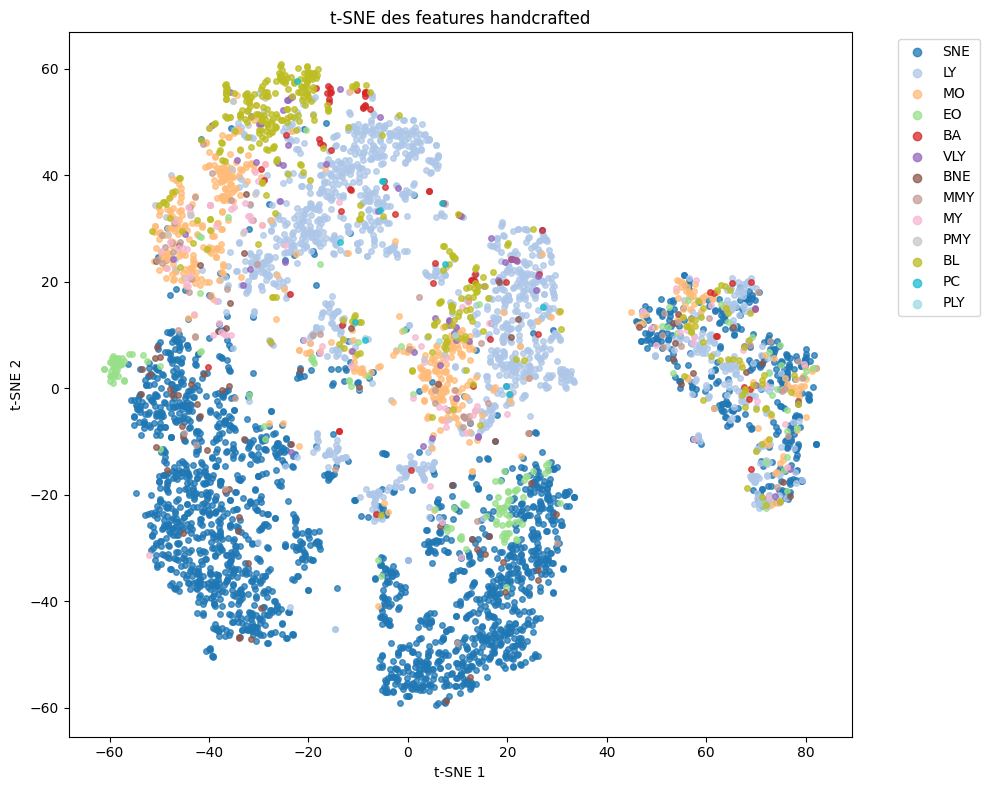

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE


def plot_tsne_features(
    X,
    y,
    label2id=None,
    sample_size=2000,
    pca_components=50,
    perplexity=30,
    random_state=42,
    figsize=(10, 8),
):
    X = np.asarray(X, dtype=np.float32)
    y = np.asarray(y)

    if sample_size is not None and len(X) > sample_size:
        rng = np.random.default_rng(random_state)
        idx = rng.choice(len(X), size=sample_size, replace=False)
        X = X[idx]
        y = y[idx]

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    n_components_pca = min(pca_components, X_scaled.shape[1], max(2, X_scaled.shape[0] - 1))
    X_pca = PCA(n_components=n_components_pca, random_state=random_state).fit_transform(X_scaled)

    try:
        tsne = TSNE(
            n_components=2,
            perplexity=perplexity,
            learning_rate="auto",
            init="pca",
            max_iter=1000,
            random_state=random_state,
        )
    except TypeError:
        tsne = TSNE(
            n_components=2,
            perplexity=perplexity,
            learning_rate="auto",
            init="pca",
            n_iter=1000,
            random_state=random_state,
        )

    X_tsne = tsne.fit_transform(X_pca)

    unique_labels = np.unique(y)

    if label2id is not None:
        id2label = {v: k for k, v in label2id.items()}
        label_names = [id2label.get(int(lbl), str(lbl)) for lbl in unique_labels]
    else:
        label_names = [str(lbl) for lbl in unique_labels]

    plt.figure(figsize=figsize)

    cmap = plt.cm.get_cmap("tab20", len(unique_labels))

    for i, lbl in enumerate(unique_labels):
        mask = y == lbl
        plt.scatter(
            X_tsne[mask, 0],
            X_tsne[mask, 1],
            s=16,
            alpha=0.75,
            color=cmap(i),
            label=label_names[i],
        )

    plt.title("t-SNE des features")
    plt.xlabel("t-SNE 1")
    plt.ylabel("t-SNE 2")
    plt.legend(markerscale=1.5, bbox_to_anchor=(1.05, 1), loc="upper left")
    plt.tight_layout()
    plt.show()

    return X_tsne, y


X_tsne, y_tsne = plot_tsne_features(
    X_tr,
    y_tr,
    label2id=label2id,
    sample_size=5000,
    pca_components=50,
    perplexity=30,
    random_state=42,
)

Shape avant: (23120, 310)
Shape après sélection: (23120, 237)


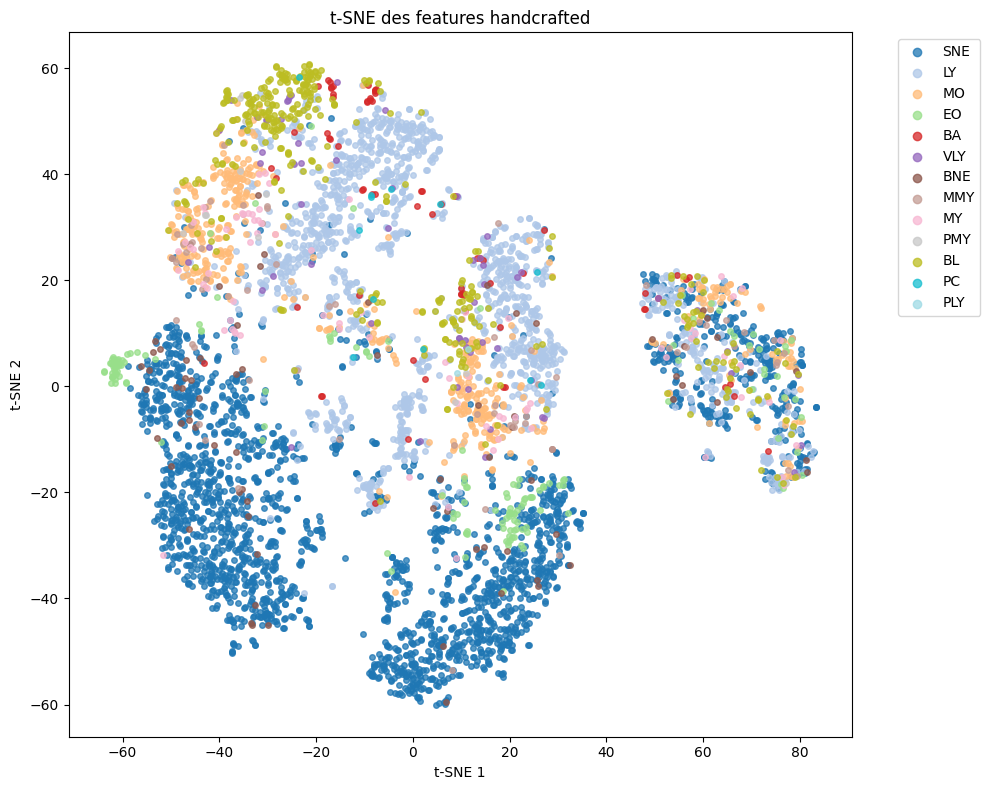

In [30]:
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectFromModel
from sklearn.linear_model import LogisticRegression

scaler = StandardScaler()
selector = SelectFromModel(
    LogisticRegression(
        penalty="l1",
        solver="saga",
        C=0.1,
        max_iter=3000,
        random_state=42
    )
)

X_tr_scaled = scaler.fit_transform(X_tr)
X_tr_selected = selector.fit_transform(X_tr_scaled, y_tr)

X_val_scaled = scaler.transform(X_val)
X_val_selected = selector.transform(X_val_scaled)

X_test_scaled = scaler.transform(X_test_features)
X_test_selected = selector.transform(X_test_scaled)


print("Shape avant:", X_tr.shape)
print("Shape après sélection:", X_tr_selected.shape)

X_tsne, y_tsne = plot_tsne_features(
    X_tr_selected,
    y_tr,
    label2id=label2id,
    sample_size=5000,
    pca_components=50,
    perplexity=30,
    random_state=42,
)

In [31]:
X_tr, y_tr = X_tr_selected, y_tr
X_val, y_val = X_val_selected, y_val
X_test = X_test_selected

# DEALING WITH UNBALANCED CLASSES

In [32]:
from imblearn.over_sampling import SMOTE
from collections import Counter


smote = SMOTE(
    sampling_strategy="auto", 
    k_neighbors=5,
    random_state=42
)

X_tr_smote, y_tr_smote = smote.fit_resample(X_tr, y_tr)

print("Avant SMOTE:", Counter(y_tr))
print("Après SMOTE:", Counter(y_tr_smote))

Avant SMOTE: Counter({np.int64(0): 10412, np.int64(1): 6480, np.int64(2): 2197, np.int64(10): 1609, np.int64(3): 689, np.int64(8): 353, np.int64(4): 332, np.int64(6): 313, np.int64(5): 293, np.int64(7): 288, np.int64(9): 91, np.int64(11): 54, np.int64(12): 9})
Après SMOTE: Counter({np.int64(1): 10412, np.int64(10): 10412, np.int64(0): 10412, np.int64(3): 10412, np.int64(6): 10412, np.int64(2): 10412, np.int64(4): 10412, np.int64(5): 10412, np.int64(7): 10412, np.int64(8): 10412, np.int64(11): 10412, np.int64(9): 10412, np.int64(12): 10412})


## LOGISTIC REGRESSION

In [33]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

clf = Pipeline([
    ("scaler", StandardScaler()),
    ("logreg", LogisticRegression(
        penalty="l2",
        C=1.0,
        solver="lbfgs",
        class_weight=None,
        max_iter=2000,
        random_state=42
    ))
])


print("Training Logistic Regression with smote...")
print(f"Training samples: {len(X_tr_smote)}, Validation samples: {len(X_val)}")

clf.fit(X_tr_smote, y_tr_smote)
y_val_pred = clf.predict(X_val)
metrics = Metrics(labels=list(label2id.values()))
metrics.update(y_val, y_val_pred)
results = metrics.compute()
print(f"Validation BACC: {results['bacc']:.4f}")
print(f"Validation Macro F1: {results['macro_f1']:.4f}")



clf = Pipeline([
    ("scaler", StandardScaler()),
    ("logreg", LogisticRegression(
        penalty="l2",
        C=1.0,
        solver="lbfgs",
        class_weight=None,
        max_iter=2000,
        random_state=42
    ))
])


print("Training Logistic Regression without smote...")
print(f"Training samples: {len(X_tr)}, Validation samples: {len(X_val)}")

clf.fit(X_tr, y_tr)
y_val_pred = clf.predict(X_val)
metrics = Metrics(labels=list(label2id.values()))
metrics.update(y_val, y_val_pred)
results = metrics.compute()
print(f"Validation BACC: {results['bacc']:.4f}")
print(f"Validation Macro F1: {results['macro_f1']:.4f}")


Training Logistic Regression with smote...
Training samples: 135356, Validation samples: 5781
Validation BACC: 0.6551
Validation Macro F1: 0.5165
Training Logistic Regression without smote...
Training samples: 23120, Validation samples: 5781
Validation BACC: 0.5071
Validation Macro F1: 0.5402


## RANDOM FOREST

In [34]:
from sklearn.ensemble import RandomForestClassifier

rf_clf = Pipeline([
    ("model", RandomForestClassifier(
        n_estimators=600,
        max_features="sqrt",
        class_weight=None,
        n_jobs=-1,
        random_state=42
    ))
])

print("Training Random Forest with smote...")
rf_clf.fit(X_tr_smote, y_tr_smote)
y_val_pred_rf = rf_clf.predict(X_val)
metrics_rf = Metrics(labels=list(label2id.values()))
metrics_rf.update(y_val, y_val_pred_rf)
results_rf = metrics_rf.compute()
print(f"Random Forest Validation BACC: {results_rf['bacc']:.4f}")
print(f"Random Forest Validation Macro F1: {results_rf['macro_f1']:.4f}")


rf_clf = Pipeline([
    ("model", RandomForestClassifier(
        n_estimators=600,
        max_features="sqrt",
        class_weight=None,
        n_jobs=-1,
        random_state=42
    ))
])

print("Training Random Forest without smote...")
rf_clf.fit(X_tr, y_tr)
y_val_pred_rf = rf_clf.predict(X_val)
metrics_rf = Metrics(labels=list(label2id.values()))
metrics_rf.update(y_val, y_val_pred_rf)
results_rf = metrics_rf.compute()
print(f"Random Forest Validation BACC: {results_rf['bacc']:.4f}")
print(f"Random Forest Validation Macro F1: {results_rf['macro_f1']:.4f}")

Training Random Forest with smote...


Random Forest Validation BACC: 0.4926
Random Forest Validation Macro F1: 0.5086
Training Random Forest without smote...
Random Forest Validation BACC: 0.3908
Random Forest Validation Macro F1: 0.4191


## SVM RBF

In [35]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

svm_rbf = Pipeline([
    ("scaler", StandardScaler()),
    ("model", SVC(
        kernel="rbf",
        C=1.0,
        gamma="scale",
        class_weight=None,
        probability=False,
        random_state=42
    ))
])

print("Training SVM with RBF kernel with smote...")
svm_rbf.fit(X_tr_smote, y_tr_smote)
y_val_pred_svm_rbf = svm_rbf.predict(X_val)
metrics_svm_rbf = Metrics(labels=list(label2id.values()))   
metrics_svm_rbf.update(y_val, y_val_pred_svm_rbf)
results_svm_rbf = metrics_svm_rbf.compute()
print(f"SVM RBF Validation BACC: {results_svm_rbf['bacc']:.4f}")
print(f"SVM RBF Validation Macro F1: {results_svm_rbf['macro_f1']:.4f}")    



svm_rbf = Pipeline([
    ("scaler", StandardScaler()),
    ("model", SVC(
        kernel="rbf",
        C=1.0,
        gamma="scale",
        class_weight=None,
        probability=False,
        random_state=42
    ))
])

print("Training SVM with RBF kernel without smote...")
svm_rbf.fit(X_tr, y_tr)
y_val_pred_svm_rbf = svm_rbf.predict(X_val)
metrics_svm_rbf = Metrics(labels=list(label2id.values()))   
metrics_svm_rbf.update(y_val, y_val_pred_svm_rbf)
results_svm_rbf = metrics_svm_rbf.compute()
print(f"SVM RBF Validation BACC: {results_svm_rbf['bacc']:.4f}")
print(f"SVM RBF Validation Macro F1: {results_svm_rbf['macro_f1']:.4f}")  

Training SVM with RBF kernel with smote...
SVM RBF Validation BACC: 0.5513
SVM RBF Validation Macro F1: 0.5388
Training SVM with RBF kernel without smote...
SVM RBF Validation BACC: 0.4174
SVM RBF Validation Macro F1: 0.4455


## XGBOOST

In [36]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=600,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="multi:softprob",
    eval_metric="mlogloss",
    num_class=len(np.unique(y_tr_smote)),
    n_jobs=-1,
    random_state=42,
    early_stopping_rounds=20
)

print("Training XGBoost with smote...")
xgb.fit(X_tr_smote, y_tr_smote, eval_set=[(X_val, y_val)], verbose=False)
y_val_pred_xgb = xgb.predict(X_val)
metrics_xgb = Metrics(labels=list(label2id.values()))
metrics_xgb.update(y_val, y_val_pred_xgb)
results_xgb = metrics_xgb.compute()
print(f"XGBoost Validation BACC: {results_xgb['bacc']:.4f}")
print(f"XGBoost Validation Macro F1: {results_xgb['macro_f1']:.4f}")    



xgb = XGBClassifier(
    n_estimators=600,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="multi:softprob",
    eval_metric="mlogloss",
    num_class=len(np.unique(y_tr)),
    n_jobs=-1,
    random_state=42,
    early_stopping_rounds=20
)

print("Training XGBoost without smote...")
xgb.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], verbose=False)
y_val_pred_xgb = xgb.predict(X_val)
metrics_xgb = Metrics(labels=list(label2id.values()))
metrics_xgb.update(y_val, y_val_pred_xgb)
results_xgb = metrics_xgb.compute()
print(f"XGBoost Validation BACC: {results_xgb['bacc']:.4f}")
print(f"XGBoost Validation Macro F1: {results_xgb['macro_f1']:.4f}")   


Training XGBoost with smote...


XGBoost Validation BACC: 0.5865
XGBoost Validation Macro F1: 0.5923
Training XGBoost without smote...
XGBoost Validation BACC: 0.4601
XGBoost Validation Macro F1: 0.4973


# CONFUSION MATRIX 

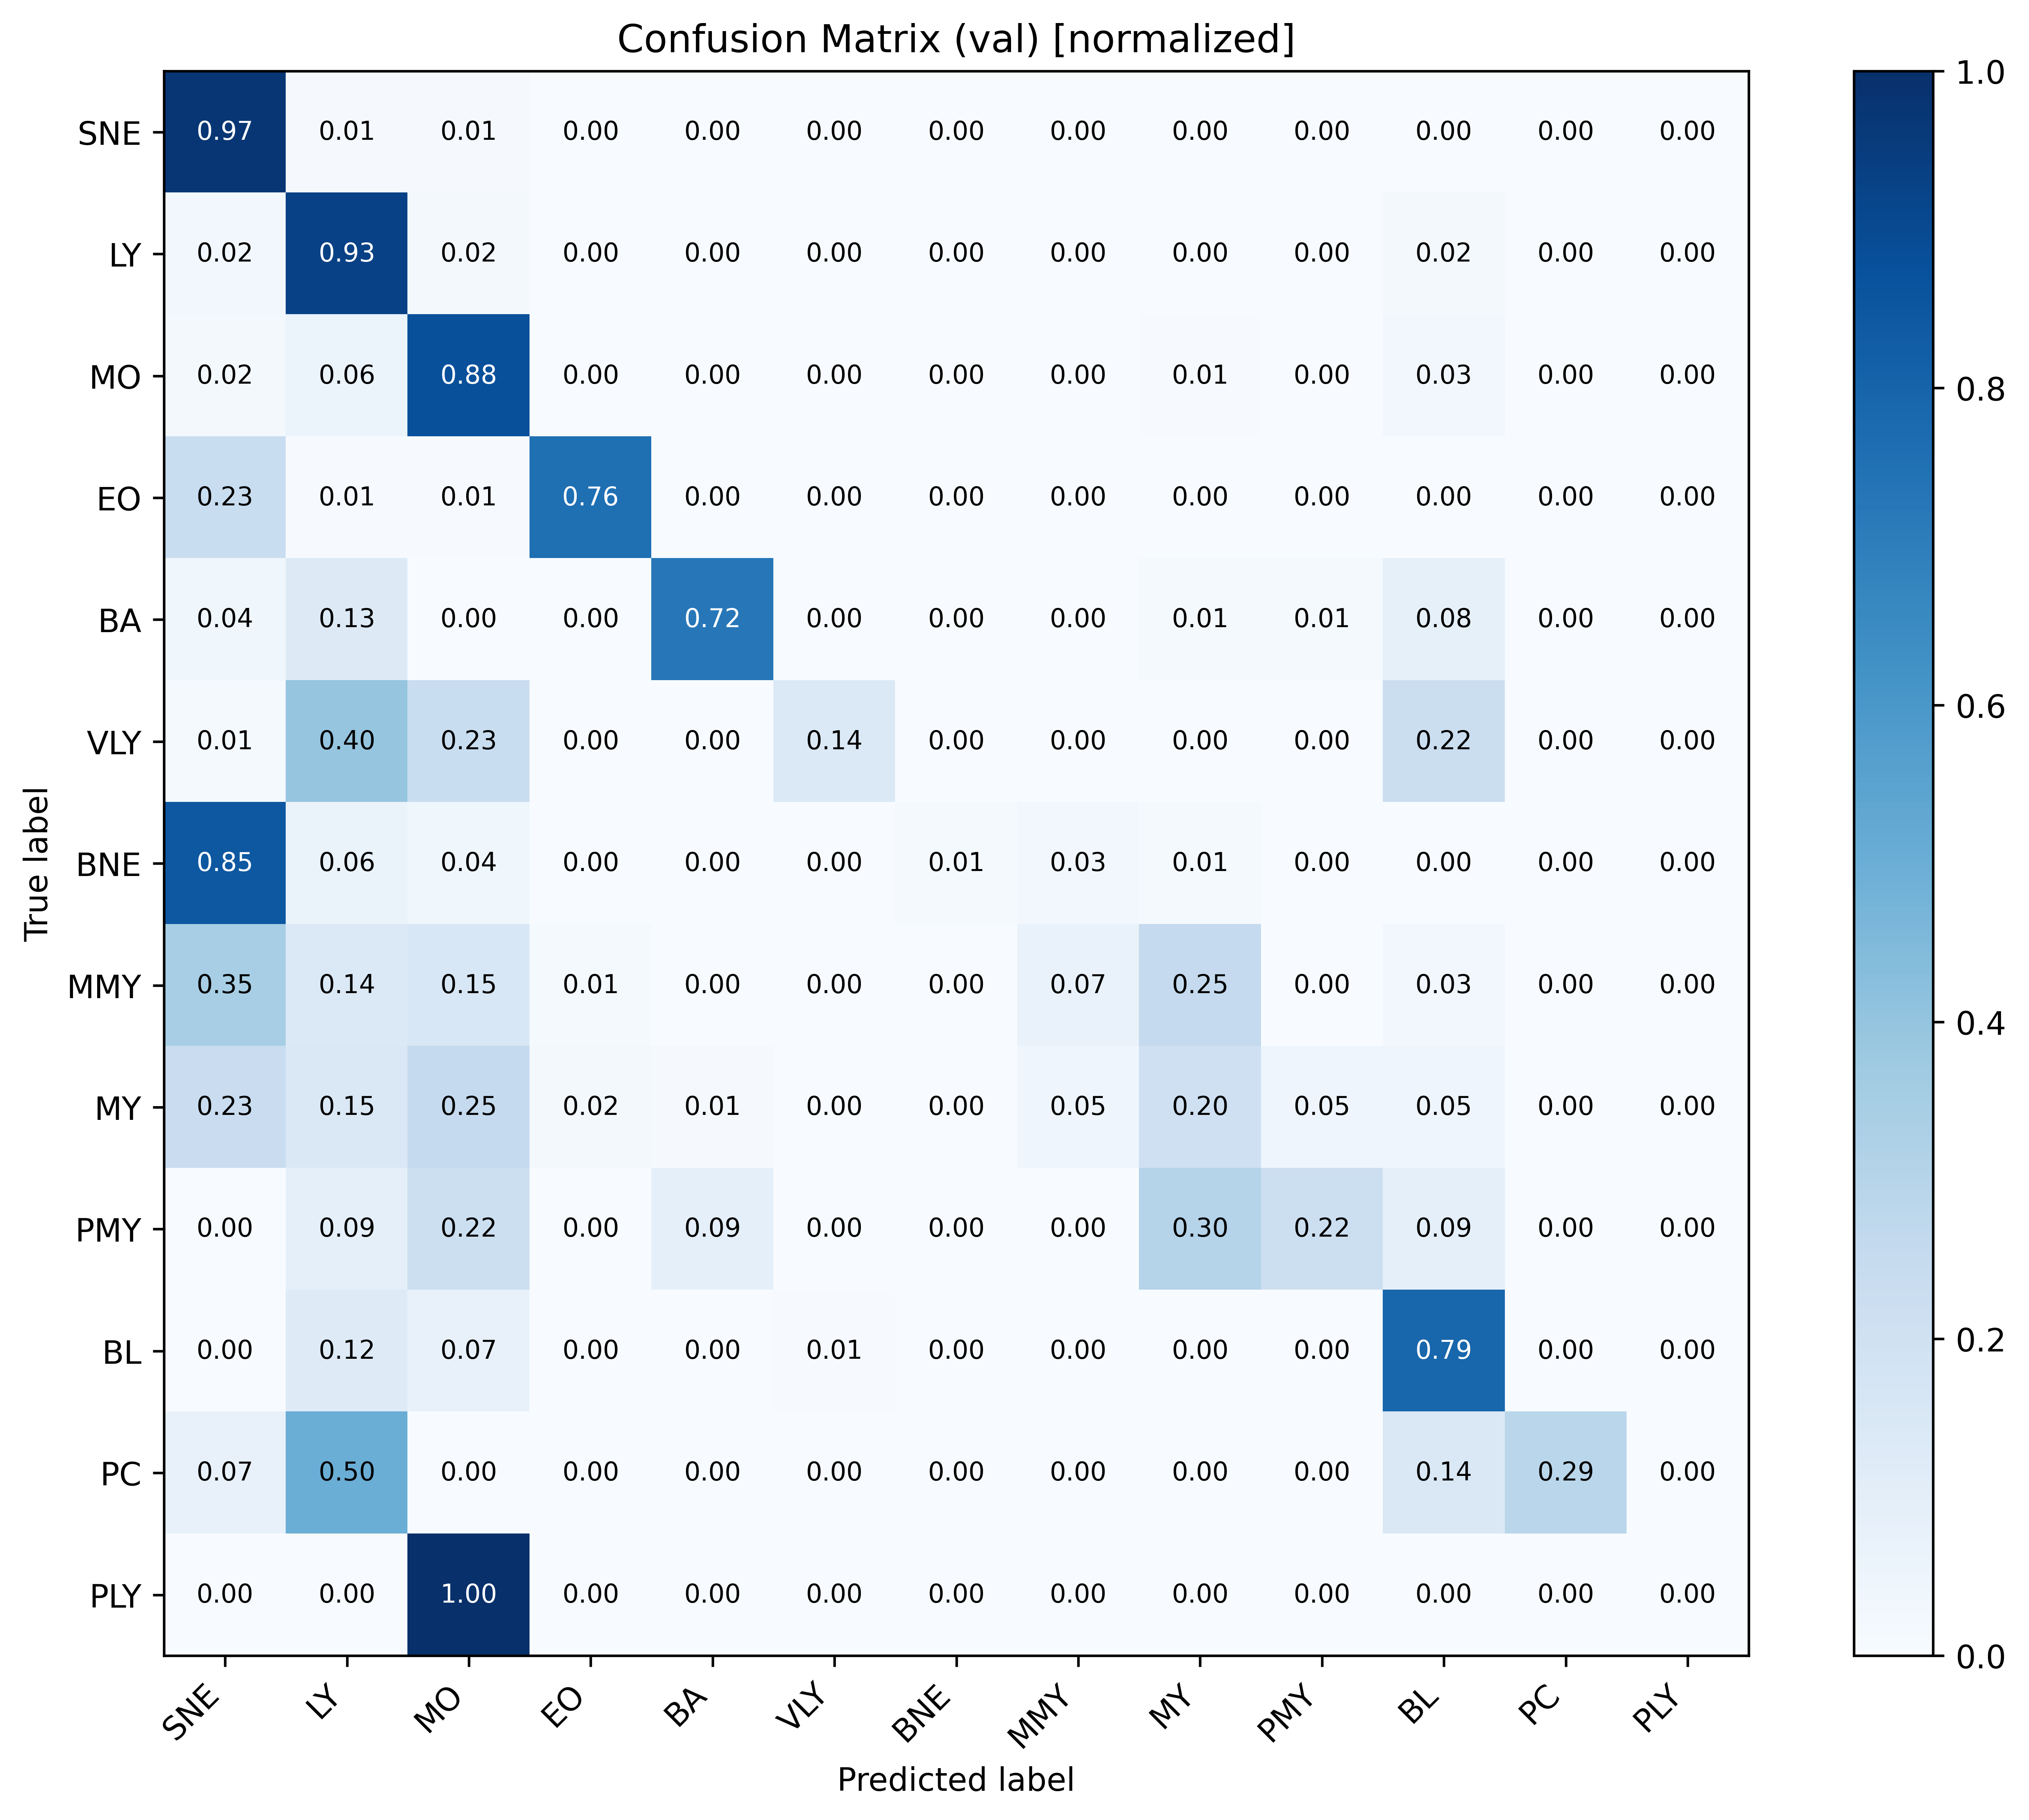

In [41]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

class_names = ["SNE", "LY", "MO", "EO", "BA", "VLY", "BNE", "MMY", "MY", "PMY", "BL", "PC", "PLY"]

normalize = True

labels = np.arange(len(class_names))
cm = confusion_matrix(y_val, y_val_pred_xgb, labels=labels)

if normalize:
    cm = cm.astype(np.float32)
    row_sums = cm.sum(axis=1, keepdims=True)
    cm = np.divide(cm, row_sums, out=np.zeros_like(cm), where=row_sums != 0)

plt.figure(figsize=(10, 8), dpi=600)
im = plt.imshow(cm, interpolation="nearest", cmap="Blues")
plt.colorbar(im)

tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names, rotation=45, ha="right")
plt.yticks(tick_marks, class_names)

fmt = ".2f" if normalize else "d"
thresh = cm.max() / 2.0 if cm.size > 0 else 0.0

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(
            j,
            i,
            format(cm[i, j], fmt),
            ha="center",
            va="center",
            color="white" if cm[i, j] > thresh else "black",
            fontsize=8,
        )

title = "Confusion Matrix (val)"
if normalize:
    title += " [normalized]"

plt.title(title)
plt.ylabel("True label")
plt.xlabel("Predicted label")
plt.tight_layout()
plt.show()

# DEEP FEATURES

In [9]:
import torch
import torch.nn as nn
from typing import Literal

from torchvision.models import (
    convnext_tiny, ConvNeXt_Tiny_Weights,
)



class Backbone(nn.Module):
    def __init__(self,):
        super().__init__()
        self.backbone = self._load_backbone()
        self.features_shape = self._get_features_shape()

    def _load_backbone(self) -> nn.Module:
        weights = ConvNeXt_Tiny_Weights.DEFAULT 
        model = convnext_tiny(weights=weights)
        return nn.Sequential(
            model.features,
            model.avgpool,
        )

    def _get_features_shape(self) -> int:
        with torch.no_grad():
            x = torch.zeros(1, 3, 224, 224)
            y = self.backbone(x)
            if isinstance(y, (tuple, list)):
                y = y[0]
            if y.dim() > 2:
                y = torch.flatten(y, 1)
        return y.shape[1]

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.backbone(x)
        if isinstance(x, (tuple, list)):
            x = x[0]
        if x.dim() > 2:
            x = torch.flatten(x, 1)
        return x




device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
convnext_tiny = Backbone().to(device)
convnext_tiny.eval()

X_train_deep_features = []
with torch.no_grad():
    for x in X_train:
        x = torch.tensor(x, dtype=torch.float32, device=device).permute(2, 0, 1).unsqueeze(0)
        feat = convnext_tiny(x).squeeze(0).cpu()
        X_train_deep_features.append(feat)

# X_test_deep_features = []
# with torch.no_grad():
#     for x in X_test:
#         print(x.shape)
#         x = torch.tensor(x, dtype=torch.float32, device=device).permute(2, 0, 1).unsqueeze(0)
#         feat = convnext_tiny(x).squeeze(0).cpu()
#         X_test_deep_features.append(feat)


In [10]:
from imblearn.over_sampling import SMOTE

X_tr, X_val, y_tr, y_val = train_test_split(
    X_train_deep_features,
    y_train,
    test_size=0.2,
    random_state=42,
    stratify=y_train
)



smote = SMOTE(
    sampling_strategy="auto", 
    k_neighbors=5,
    random_state=42
)

X_tr_smote, y_tr_smote = smote.fit_resample(X_tr, y_tr)

In [11]:
print(X_train_deep_features[0].shape)

torch.Size([768])


/tmp/ipykernel_3448795/170244233.py:61: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab20", len(unique_labels))


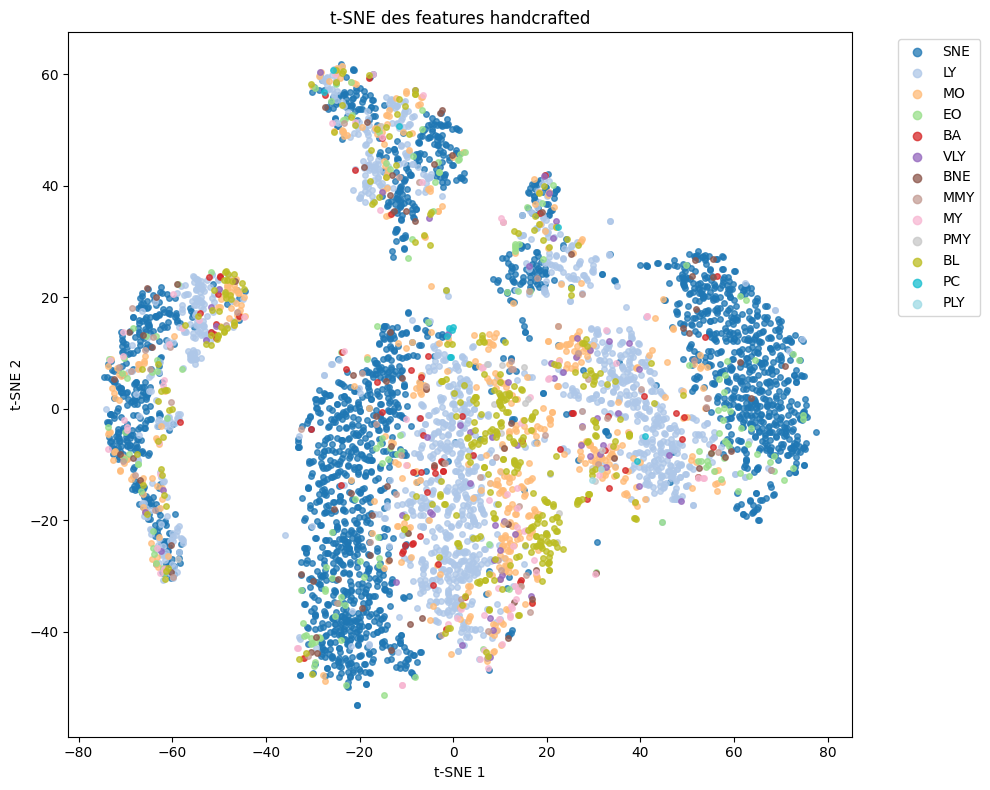

In [12]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

def plot_tsne_features(
    X,
    y,
    label2id=None,
    sample_size=2000,
    pca_components=50,
    perplexity=30,
    random_state=42,
    figsize=(10, 8),
):
    X = np.asarray(X, dtype=np.float32)
    y = np.asarray(y)

    if sample_size is not None and len(X) > sample_size:
        rng = np.random.default_rng(random_state)
        idx = rng.choice(len(X), size=sample_size, replace=False)
        X = X[idx]
        y = y[idx]

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    n_components_pca = min(pca_components, X_scaled.shape[1], max(2, X_scaled.shape[0] - 1))
    X_pca = PCA(n_components=n_components_pca, random_state=random_state).fit_transform(X_scaled)

    try:
        tsne = TSNE(
            n_components=2,
            perplexity=perplexity,
            learning_rate="auto",
            init="pca",
            max_iter=1000,
            random_state=random_state,
        )
    except TypeError:
        tsne = TSNE(
            n_components=2,
            perplexity=perplexity,
            learning_rate="auto",
            init="pca",
            n_iter=1000,
            random_state=random_state,
        )

    X_tsne = tsne.fit_transform(X_pca)

    unique_labels = np.unique(y)

    if label2id is not None:
        id2label = {v: k for k, v in label2id.items()}
        label_names = [id2label.get(int(lbl), str(lbl)) for lbl in unique_labels]
    else:
        label_names = [str(lbl) for lbl in unique_labels]

    plt.figure(figsize=figsize)

    cmap = plt.cm.get_cmap("tab20", len(unique_labels))

    for i, lbl in enumerate(unique_labels):
        mask = y == lbl
        plt.scatter(
            X_tsne[mask, 0],
            X_tsne[mask, 1],
            s=16,
            alpha=0.75,
            color=cmap(i),
            label=label_names[i],
        )

    plt.title("t-SNE des features handcrafted")
    plt.xlabel("t-SNE 1")
    plt.ylabel("t-SNE 2")
    plt.legend(markerscale=1.5, bbox_to_anchor=(1.05, 1), loc="upper left")
    plt.tight_layout()
    plt.show()

    return X_tsne, y


X_tsne, y_tsne = plot_tsne_features(
    X_tr,
    y_tr,
    label2id=label2id,
    sample_size=5000,
    pca_components=50,
    perplexity=30,
    random_state=42,
)

In [13]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression 
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier


clf = Pipeline([
    ("scaler", StandardScaler()),
    ("logreg", LogisticRegression(
        penalty="l2",
        C=1.0,
        solver="lbfgs",
        class_weight=None,
        max_iter=2000,
        random_state=42
    ))
])


rf_clf = Pipeline([
    ("model", RandomForestClassifier(
        n_estimators=600,
        max_features="sqrt",
        class_weight=None,
        n_jobs=-1,
        random_state=42
    ))
])

svm_rbf = Pipeline([
    ("scaler", StandardScaler()),
    ("model", SVC(
        kernel="rbf",
        C=1.0,
        gamma="scale",
        class_weight=None,
        probability=False,
        random_state=42
    ))
])


xgb = XGBClassifier(
    n_estimators=600,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="multi:softprob",
    eval_metric="mlogloss",
    num_class=len(np.unique(y_tr_smote)),
    n_jobs=-1,
    random_state=42,
    early_stopping_rounds=20
)


print("Training Logistic Regression on deep features...")
print(f"Training samples: {len(X_tr_smote)}, Validation samples: {len(X_val)}")
clf.fit(X_tr_smote, y_tr_smote)
y_val_pred = clf.predict(X_val)
metrics = Metrics(labels=list(label2id.values()))
metrics.update(y_val, y_val_pred)
results = metrics.compute()
print(f"Validation BACC: {results['bacc']:.4f}")
print(f"Validation Macro F1: {results['macro_f1']:.4f}")


print("Training Random Forest on deep features...")
rf_clf.fit(X_tr_smote, y_tr_smote)
y_val_pred_rf = rf_clf.predict(X_val)
metrics_rf = Metrics(labels=list(label2id.values()))
metrics_rf.update(y_val, y_val_pred_rf)
results_rf = metrics_rf.compute()
print(f"Random Forest Validation BACC: {results_rf['bacc']:.4f}")
print(f"Random Forest Validation Macro F1: {results_rf['macro_f1']:.4f}")   


print("Training SVM with RBF kernel on deep features...")
svm_rbf.fit(X_tr_smote, y_tr_smote)
y_val_pred_svm_rbf = svm_rbf.predict(X_val)
metrics_svm_rbf = Metrics(labels=list(label2id.values()))
metrics_svm_rbf.update(y_val, y_val_pred_svm_rbf)
results_svm_rbf = metrics_svm_rbf.compute()
print(f"SVM RBF Validation BACC: {results_svm_rbf['bacc']:.4f}")
print(f"SVM RBF Validation Macro F1: {results_svm_rbf['macro_f1']:.4f}")    


print("Training XGBoost on deep features...")
xgb.fit(X_tr_smote, y_tr_smote, eval_set=[(X_val, y_val)], verbose=False)
y_val_pred_xgb = xgb.predict(X_val)
metrics_xgb = Metrics(labels=list(label2id.values()))
metrics_xgb.update(y_val, y_val_pred_xgb)
results_xgb = metrics_xgb.compute()
print(f"XGBoost Validation BACC: {results_xgb['bacc']:.4f}")
print(f"XGBoost Validation Macro F1: {results_xgb['macro_f1']:.4f}")    


Training Logistic Regression on deep features...
Training samples: 135356, Validation samples: 5781


/home/infres/yrothlin-24/.local/share/mamba/envs/IM05/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


Validation BACC: 0.5443
Validation Macro F1: 0.4997
Training Random Forest on deep features...
Random Forest Validation BACC: 0.4016
Random Forest Validation Macro F1: 0.4315
Training SVM with RBF kernel on deep features...
SVM RBF Validation BACC: 0.5371
SVM RBF Validation Macro F1: 0.5480
Training XGBoost on deep features...
XGBoost Validation BACC: 0.5300
XGBoost Validation Macro F1: 0.5668


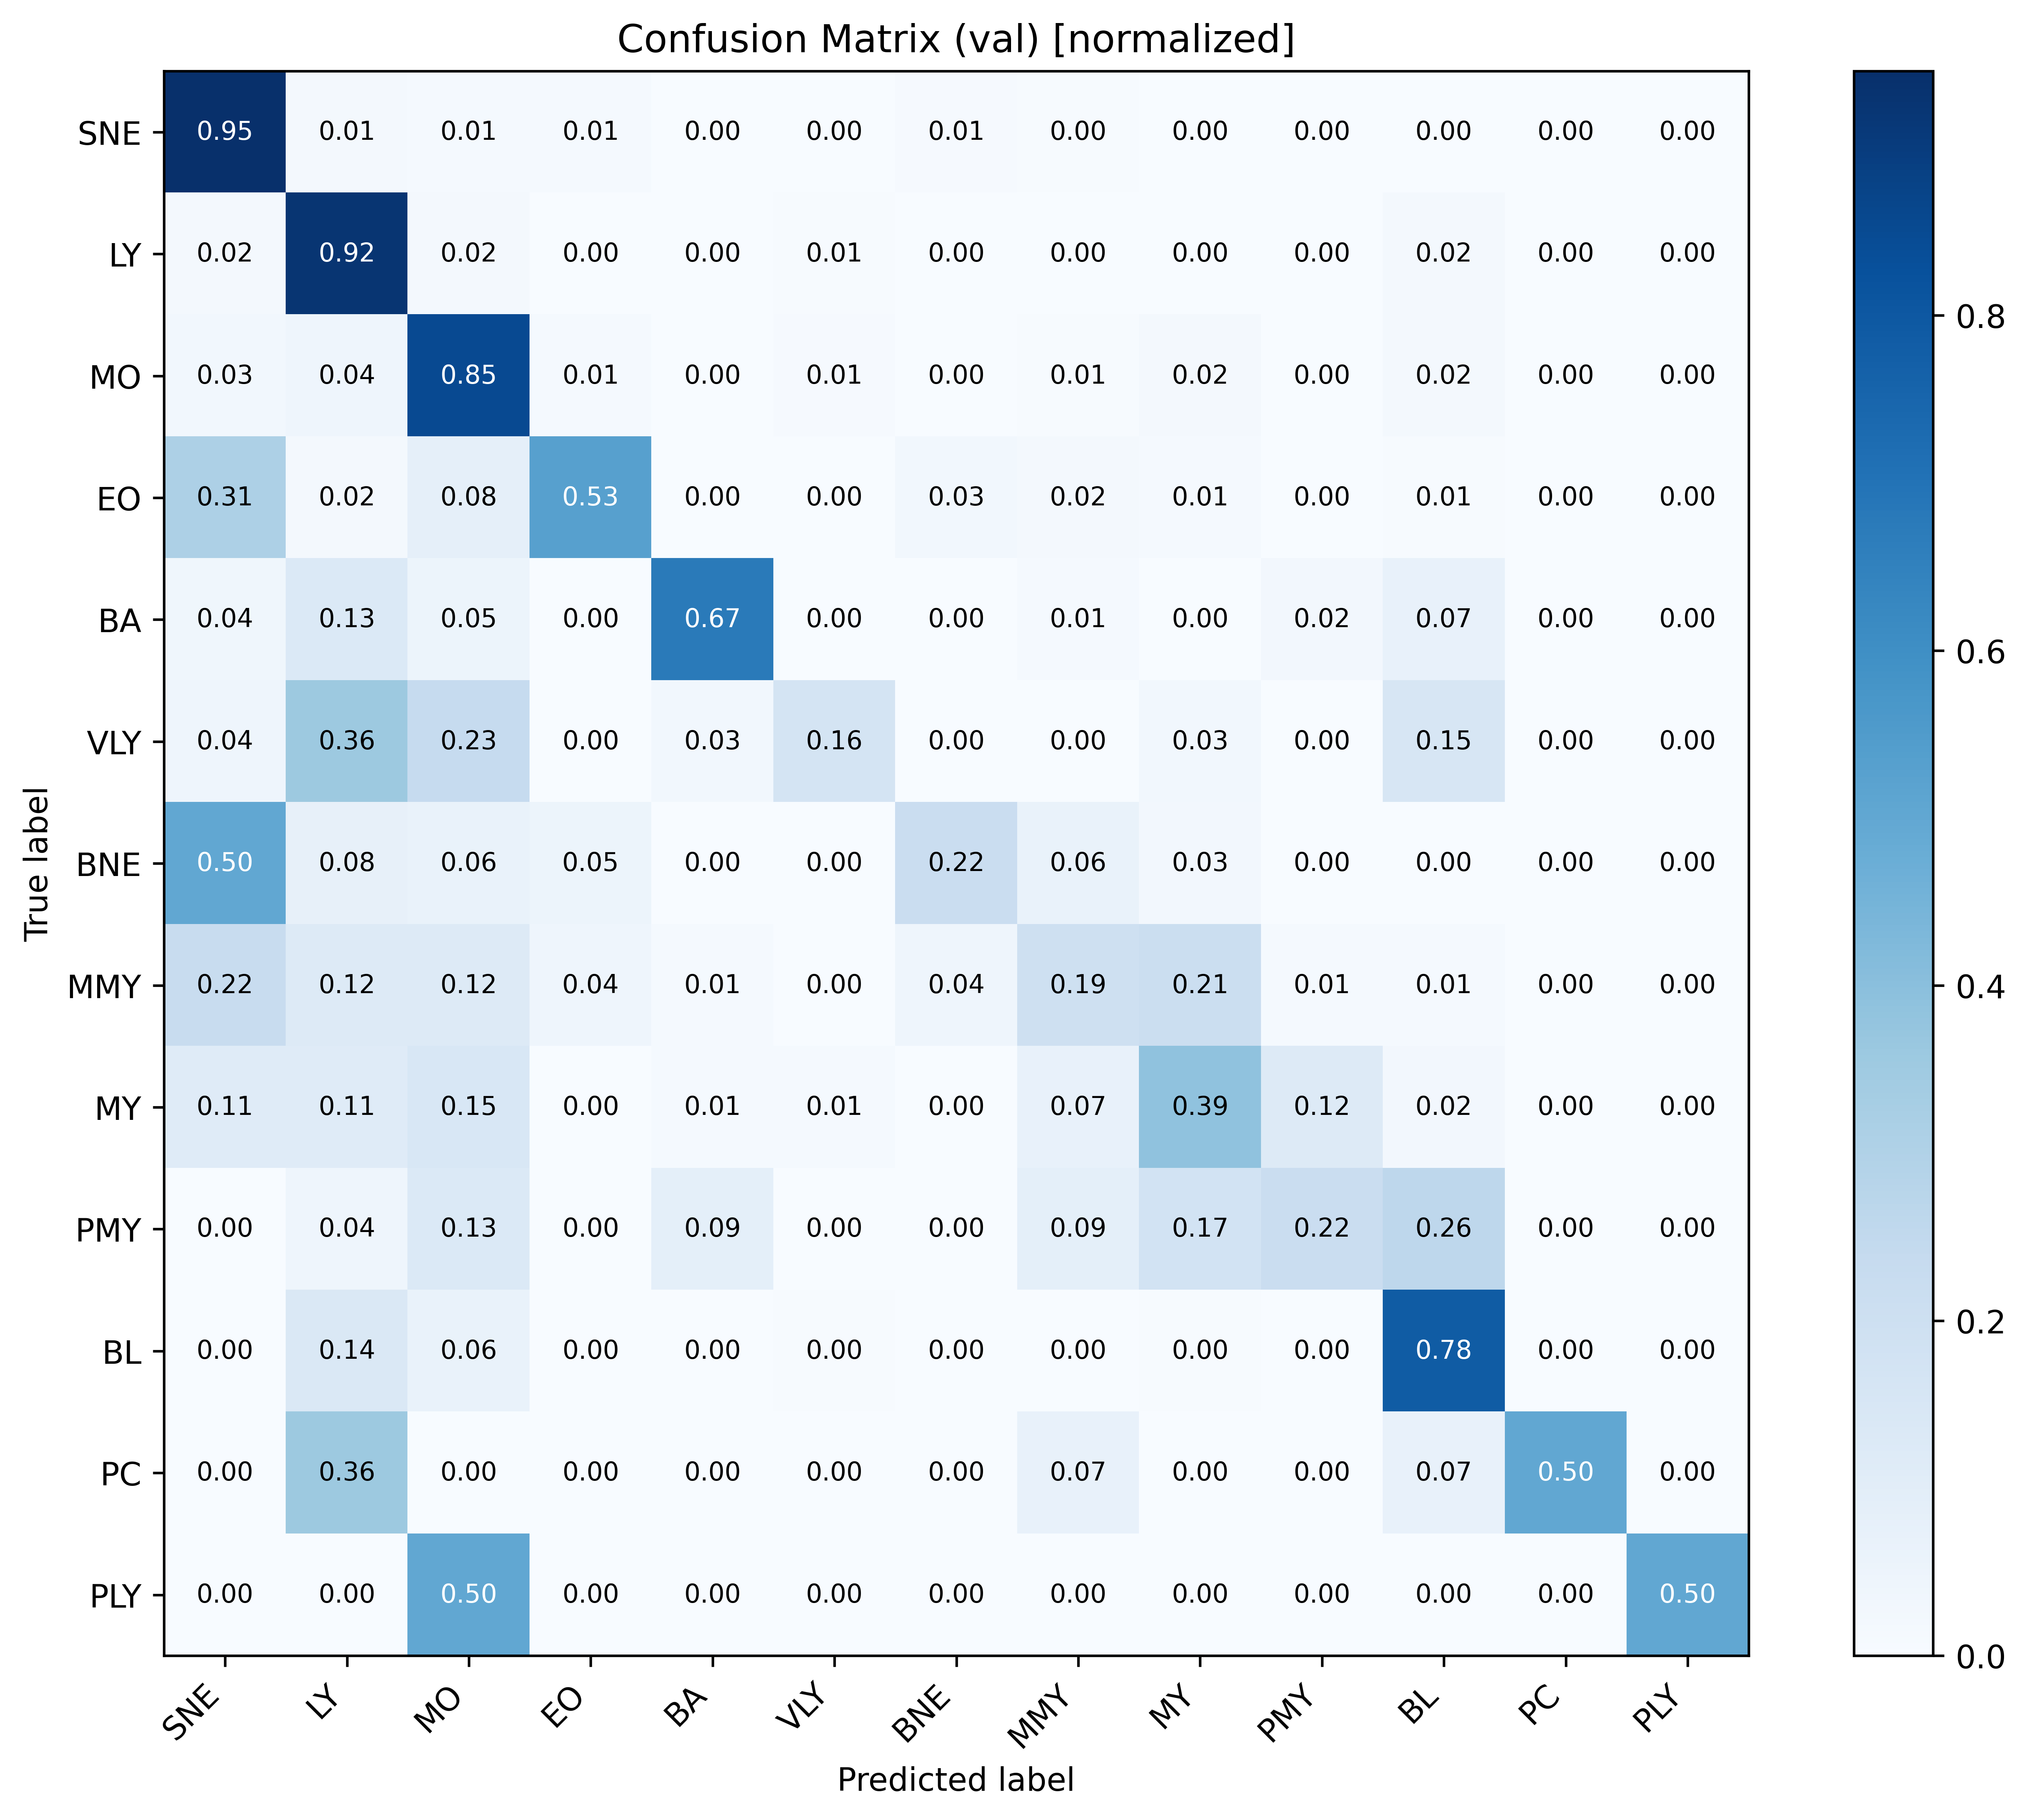

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

class_names = ["SNE", "LY", "MO", "EO", "BA", "VLY", "BNE", "MMY", "MY", "PMY", "BL", "PC", "PLY"]

normalize = True

labels = np.arange(len(class_names))
cm = confusion_matrix(y_val, y_val_pred_xgb, labels=labels)

if normalize:
    cm = cm.astype(np.float32)
    row_sums = cm.sum(axis=1, keepdims=True)
    cm = np.divide(cm, row_sums, out=np.zeros_like(cm), where=row_sums != 0)

plt.figure(figsize=(10, 8), dpi=600)
im = plt.imshow(cm, interpolation="nearest", cmap="Blues")
plt.colorbar(im)

tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names, rotation=45, ha="right")
plt.yticks(tick_marks, class_names)

fmt = ".2f" if normalize else "d"
thresh = cm.max() / 2.0 if cm.size > 0 else 0.0

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(
            j,
            i,
            format(cm[i, j], fmt),
            ha="center",
            va="center",
            color="white" if cm[i, j] > thresh else "black",
            fontsize=8,
        )

title = "Confusion Matrix (val)"
if normalize:
    title += " [normalized]"

plt.title(title)
plt.ylabel("True label")
plt.xlabel("Predicted label")
plt.tight_layout()
plt.show()